In [1]:
pip install yfinance pandas numpy matplotlib statsmodels pandas-datareader openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas_datareader import data as web
import statsmodels.api as sm

In [3]:
stock="TCS.NS"
start_date="2021-08-02"
end_date="2026-08-01"

In [4]:
stock_data=yf.download(
    stock,
    start=start_date,
    end=end_date,
    auto_adjust=True,
)

[*********************100%***********************]  1 of 1 completed


In [5]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2021-08-02,2796.688232,2801.466075,2751.168510,2762.461592,2608669
2021-08-03,2853.588135,2858.018583,2796.297501,2805.027965,3804735
2021-08-04,2844.074951,2871.221775,2832.999047,2866.704586,2929598
2021-08-05,2852.762695,2879.735829,2834.129153,2844.987885,2534521
2021-08-06,2875.218018,2887.553492,2836.300287,2842.859002,2292362


In [6]:
stock_data["Daily_Returns"]=stock_data["Close"].pct_change()

In [7]:
stock_data["Close"]

Ticker,TCS.NS
Date,
2021-08-02,2796.688232
2021-08-03,2853.588135
2021-08-04,2844.074951
2021-08-05,2852.762695
2021-08-06,2875.218018
...,...
2026-07-27,2295.600098
2026-07-28,2398.000000
2026-07-29,2446.600098


In [8]:
stock_data = stock_data.dropna()

In [9]:
stock_data.head()

Price,Close,High,Low,Open,Volume,Daily_Returns
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,
Date,,,,,,
2021-08-03,2853.588135,2858.018583,2796.297501,2805.027965,3804735,0.020345
2021-08-04,2844.074951,2871.221775,2832.999047,2866.704586,2929598,-0.003334
2021-08-05,2852.762695,2879.735829,2834.129153,2844.987885,2534521,0.003055
2021-08-06,2875.218018,2887.553492,2836.300287,2842.859002,2292362,0.007871
2021-08-09,2886.424805,2898.847237,2875.392375,2887.467201,1510489,0.003898


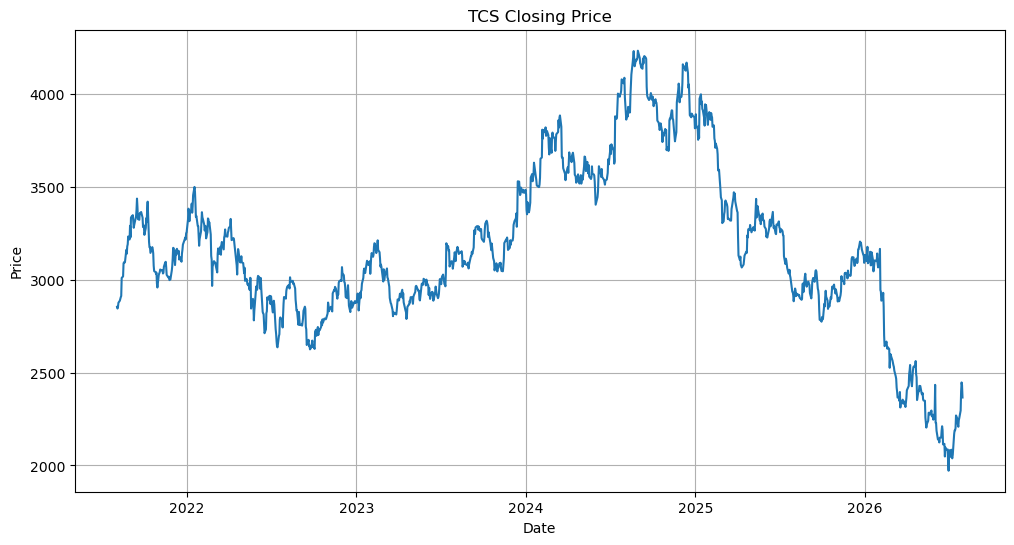

In [10]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index,stock_data["Close"])
plt.title("TCS Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid("True")
plt.savefig("TCS_Closing_Price.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
stock="TCS.NS"
start_date="2021-08-02"
end_date="2026-08-01"
stock_data=yf.download(
    stock,
    start=start_date,
    end=end_date,
    auto_adjust=True
)
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2021-08-02,2796.688232,2801.466075,2751.168510,2762.461592,2608669
2021-08-03,2853.588135,2858.018583,2796.297501,2805.027965,3804735
2021-08-04,2844.074951,2871.221775,2832.999047,2866.704586,2929598
2021-08-05,2852.762695,2879.735829,2834.129153,2844.987885,2534521
2021-08-06,2875.218018,2887.553492,2836.300287,2842.859002,2292362


In [12]:
stock_data["Return"]=stock_data["Close"].pct_change()
stock_data=stock_data.dropna()
stock_data.head()

Price,Close,High,Low,Open,Volume,Return
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,
Date,,,,,,
2021-08-03,2853.588135,2858.018583,2796.297501,2805.027965,3804735,0.020345
2021-08-04,2844.074951,2871.221775,2832.999047,2866.704586,2929598,-0.003334
2021-08-05,2852.762695,2879.735829,2834.129153,2844.987885,2534521,0.003055
2021-08-06,2875.218018,2887.553492,2836.300287,2842.859002,2292362,0.007871
2021-08-09,2886.424805,2898.847237,2875.392375,2887.467201,1510489,0.003898


In [13]:
ff_data=web.DataReader(
    "F-F_Research_Data_Factors_daily",
    "famafrench"
)

In [14]:
type(ff_data)

dict

In [15]:
ff_data.keys()

dict_keys([0, 'DESCR'])

In [16]:
factors=ff_data[0]
factors.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2021-09-07,-0.36,-0.13,-0.08,0.0
2021-09-08,-0.33,-0.82,0.07,0.0
2021-09-09,-0.28,0.24,0.09,0.0
2021-09-10,-0.76,-0.08,0.02,0.0
2021-09-13,0.14,-0.07,1.35,0.0


In [17]:
stock_data=stock_data.reset_index()
stock_data.head()

Price,Date,Close,High,Low,Open,Volume,Return
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,
0,2021-08-03,2853.588135,2858.018583,2796.297501,2805.027965,3804735,0.020345
1,2021-08-04,2844.074951,2871.221775,2832.999047,2866.704586,2929598,-0.003334
2,2021-08-05,2852.762695,2879.735829,2834.129153,2844.987885,2534521,0.003055
3,2021-08-06,2875.218018,2887.553492,2836.300287,2842.859002,2292362,0.007871
4,2021-08-09,2886.424805,2898.847237,2875.392375,2887.467201,1510489,0.003898


In [18]:
stock_returns=stock_data[["Date","Return"]].copy()
stock_returns.head()

Price,Date,Return
Ticker,,
0,2021-08-03,0.020345
1,2021-08-04,-0.003334
2,2021-08-05,0.003055
3,2021-08-06,0.007871
4,2021-08-09,0.003898


In [19]:
stock_returns["Return"]=stock_returns["Return"]*100
stock_returns.head()

Price,Date,Return
Ticker,,
0,2021-08-03,2.034546
1,2021-08-04,-0.333376
2,2021-08-05,0.305468
3,2021-08-06,0.787143
4,2021-08-09,0.389772


In [20]:
factors=factors.reset_index()
factors.head()

,Date,Mkt-RF,SMB,HML,RF
0,2021-09-07,-0.36,-0.13,-0.08,0.0
1,2021-09-08,-0.33,-0.82,0.07,0.0
2,2021-09-09,-0.28,0.24,0.09,0.0
3,2021-09-10,-0.76,-0.08,0.02,0.0
4,2021-09-13,0.14,-0.07,1.35,0.0


In [21]:
stock_returns.columns

MultiIndex([(  'Date', ''),
            ('Return', '')],
           names=['Price', 'Ticker'])

In [22]:
stock_returns.columns = stock_returns.columns.get_level_values(0)

stock_returns.head()

Price,Date,Return
0,2021-08-03,2.034546
1,2021-08-04,-0.333376
2,2021-08-05,0.305468
3,2021-08-06,0.787143
4,2021-08-09,0.389772


In [23]:
stock_returns.columns

Index(['Date', 'Return'], dtype='object', name='Price')

In [24]:
merged_data = pd.merge(
    stock_returns,
    factors,
    on="Date",
    how="inner"
)

In [25]:
print(stock_returns["Date"].head())
print(factors["Date"].head())
print(stock_returns.shape)
print(factors.shape)
print(merged_data.shape)

0   2021-08-03
1   2021-08-04
2   2021-08-05
3   2021-08-06
4   2021-08-09
Name: Date, dtype: datetime64[ns]
0    2021-09-07
1    2021-09-08
2    2021-09-09
3    2021-09-10
4    2021-09-13
Name: Date, dtype: period[D]
(1238, 2)
(1208, 5)
(0, 6)


In [26]:
factors["Date"] = factors["Date"].dt.to_timestamp()

In [27]:
print(factors["Date"].dtype)

datetime64[ns]


In [28]:
merged_data = pd.merge(
    stock_returns,
    factors,
    on="Date",
    how="inner"
)

merged_data.head()

,Date,Return,Mkt-RF,SMB,HML,RF
0,2021-09-07,-0.937178,-0.36,-0.13,-0.08,0.0
1,2021-09-08,-1.094111,-0.33,-0.82,0.07,0.0
2,2021-09-09,0.457043,-0.28,0.24,0.09,0.0
3,2021-09-13,1.422963,0.14,-0.07,1.35,0.0
4,2021-09-14,1.054509,-0.66,-0.49,-0.97,0.0


In [29]:
merged_data["Excess_Return"]=merged_data["Return"]-merged_data["RF"]
merged_data.head()

,Date,Return,Mkt-RF,SMB,HML,RF,Excess_Return
0,2021-09-07,-0.937178,-0.36,-0.13,-0.08,0.0,-0.937178
1,2021-09-08,-1.094111,-0.33,-0.82,0.07,0.0,-1.094111
2,2021-09-09,0.457043,-0.28,0.24,0.09,0.0,0.457043
3,2021-09-13,1.422963,0.14,-0.07,1.35,0.0,1.422963
4,2021-09-14,1.054509,-0.66,-0.49,-0.97,0.0,1.054509


In [30]:
X = merged_data[["Mkt-RF", "SMB", "HML"]]

X.head()

,Mkt-RF,SMB,HML
0,-0.36,-0.13,-0.08
1,-0.33,-0.82,0.07
2,-0.28,0.24,0.09
3,0.14,-0.07,1.35
4,-0.66,-0.49,-0.97


In [31]:
Y = merged_data["Excess_Return"]

Y.head()

0   -0.937178
1   -1.094111
2    0.457043
3    1.422963
4    1.054509
Name: Excess_Return, dtype: float64

In [32]:
X = sm.add_constant(X)

X.head()

,const,Mkt-RF,SMB,HML
0,1.0,-0.36,-0.13,-0.08
1,1.0,-0.33,-0.82,0.07
2,1.0,-0.28,0.24,0.09
3,1.0,0.14,-0.07,1.35
4,1.0,-0.66,-0.49,-0.97


In [33]:
model = sm.OLS(Y, X).fit()

In [34]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     9.461
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           3.55e-06
Time:                        11:45:17   Log-Likelihood:                -1991.9
No. Observations:                1150   AIC:                             3992.
Df Residuals:                    1146   BIC:                             4012.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0563      0.041     -1.389      0.1

In [35]:
with open("Regression_Summary.txt", "w") as f:
    f.write(model.summary().as_text())

In [36]:
results = pd.DataFrame({
    "Coefficient": model.params,
    "P-Value": model.pvalues,
    "T-Statistic": model.tvalues
})

results

,Coefficient,P-Value,T-Statistic
const,-0.056299,0.164952,-1.389496
Mkt-RF,0.189994,0.000003,4.688513
SMB,-0.037456,0.552078,-0.594825
HML,-0.020099,0.682540,-0.409104


In [37]:
results.to_excel("Regression_Coefficients.xlsx")

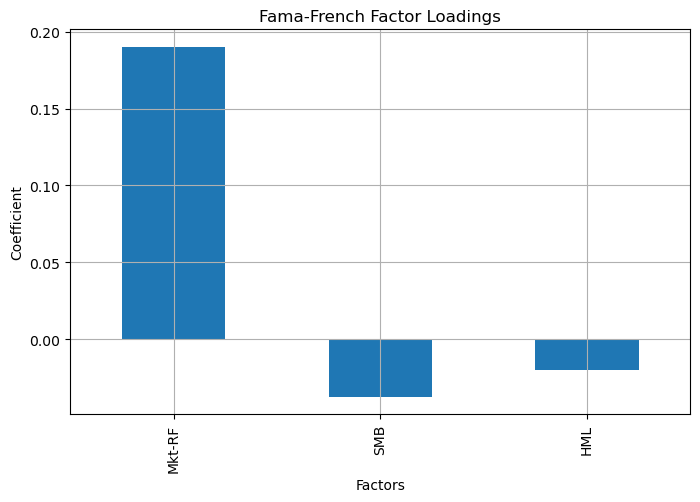

In [38]:
coefficients = model.params.drop("const")

plt.figure(figsize=(8,5))

coefficients.plot(kind="bar")

plt.title("Fama-French Factor Loadings")
plt.xlabel("Factors")
plt.ylabel("Coefficient")

plt.grid(True)

plt.savefig("Factor_Loadings.png", dpi=300, bbox_inches="tight")

plt.show()

## Conclusion

This analysis examined the return behaviour of Tata Consultancy Services (TCS) using the Fama-French Three-Factor Model. The regression results indicate that the **market risk factor (Mkt-RF)** is statistically significant, with a factor loading of approximately **0.19**, suggesting that TCS's excess returns had a positive relationship with market excess returns during the sample period.

In contrast, the **SMB (size)** and **HML (value)** factors were not statistically significant, indicating limited evidence that size and value characteristics explained TCS's excess returns in this sample. The model produced a relatively low **R-squared of approximately 2.4%**, suggesting that the three factors explain only a small proportion of the variation in TCS's returns.

### Limitations of the Regression Results

* **Low explanatory power:** The R-squared of approximately 2.4% indicates that the three factors explain only a small proportion of the variation in TCS's excess returns.
* **Limited factor significance:** Only the Mkt-RF factor is statistically significant, while SMB and HML are not statistically significant in this sample.
* **Non-normal residuals:** The regression diagnostics indicate deviations from normality, including high kurtosis and a significant Jarque-Bera test, suggesting the presence of extreme return observations.
* **Non-robust standard errors:** The regression uses conventional standard errors. If heteroskedasticity is present, the reported standard errors and significance levels may not be fully reliable.
* **Single-stock analysis:** Since the analysis focuses only on TCS, the results cannot be generalized directly to the broader Indian equity market.
* **Model limitations:** The three-factor model does not capture other potential return drivers such as momentum, profitability, investment characteristics, sector effects, or company-specific events.

Overall, the findings demonstrate the usefulness of factor-based regression for evaluating equity return drivers while also highlighting its limitations when applied to an individual stock. Therefore, these results should be interpreted as **historical empirical evidence rather than as a standalone basis for investment decisions**. Further analysis using additional factors, robust standard errors, longer sample periods, or alternative asset-pricing models could provide a more comprehensive explanation of TCS's return behaviour.
